# 04 — Validation principale

Validation sur **vrais commits** : position des tests critiques (score=1.0) + validation par **injection de bug réel** (`account_move.py`).

**Entrée** : `artifacts/dataset_scored.pkl`, `artifacts/embeddings_sbert.pkl`, `models/ranker_full.pkl`.

In [1]:
# ── Chemins relatifs au package (portable) ──
from pathlib import Path
import os
ROOT = Path.cwd()
if ROOT.name == 'scripts':
    ROOT = ROOT.parent         
elif (ROOT / 'scripts').exists():
    pass                        
DATA = ROOT / 'data'
ARTIFACTS = ROOT / 'artifacts'
MODELS = ROOT / 'models'
ARTIFACTS.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
print('Racine du package :', ROOT)

Racine du package : c:\Users\LEGION\OneDrive\Bureau\package_evaluation


In [3]:
import pandas as pd, numpy as np, re, pickle, joblib
import xgboost as xgb
from sklearn.metrics.pairwise import cosine_similarity
# Désactive les avertissements non critiques et fixe la graine pour la reproductibilité
import warnings; warnings.filterwarnings('ignore'); np.random.seed(42)

# Chargement des artefacts produits par les notebooks précédents.
# dataset_scored.pkl contient déjà la colonne rank_score (prédictions du ranker
# en LOO-CV) : la validation s'appuie sur ces scores, sans réentraîner de modèle.
df = pd.read_pickle(ARTIFACTS/'dataset_scored.pkl')
emb = pickle.load(open(ARTIFACTS/'embeddings_sbert.pkl','rb'))
test_emb_sbert = emb['test_emb_sbert']; diff_emb_sbert = emb['diff_emb_sbert']
reverse_deps = pickle.load(open(ARTIFACTS/'reverse_deps.pkl','rb'))
GENERIC_WORDS = pickle.load(open(ARTIFACTS/'generic.pkl','rb'))
FEATURES = pickle.load(open(MODELS/'feature_list.pkl','rb'))

# Modèle SBERT (rechargé pour d'éventuels calculs de similarité dans la validation)
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Liste des commits et fonction de conversion score continu -> grade discret
# (réutilisée pour la cohérence avec l'entraînement).
commit_ids = df.commit_id.unique().tolist()
def score_to_grade(s):
    if s>=1.0: return 5
    if s>=0.8: return 4
    if s>=0.5: return 3
    if s>=0.3: return 2
    if s>=0.15: return 1
    return 0
print('Setup validation OK :', df.shape, '| scores chargés depuis dataset_scored.pkl')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Setup validation OK : (263649, 34) | scores chargés depuis dataset_scored.pkl


## Position des tests critiques

In [4]:
# ── VALIDATION RÉELLE — Position des tests critiques ─────
print('VALIDATION : Position des tests directement liés au commit')

all_positions = []

for test_cid in commit_ids:
    dc = df[df.commit_id == test_cid].copy()
    
    # Tests avec score 1.0 = directement dans le diff
    critical_tests = dc[dc.relevance_score == 1.0]
    if len(critical_tests) == 0:
        continue
    
    # Ranking du modèle
    dc_sorted = dc.sort_values('rank_score', ascending=False).reset_index()
    total = len(dc_sorted)
    
    print(f"\n  {test_cid} ({total:,} tests)")
    print(f"  Tests critiques (score=1.0) : {len(critical_tests)}")
    
    for _, ct in critical_tests.iterrows():
        pos = dc_sorted[dc_sorted.test_name == ct['test_name']].index[0] + 1
        pct = pos / total * 100
        all_positions.append(pct)
        print(f"    {ct['test_name'][:60]:<60} → position {pos:>5}/{total} (top {pct:.1f}%)")
    
    positions = []
    for _, ct in critical_tests.iterrows():
        pos = dc_sorted[dc_sorted.test_name == ct['test_name']].index[0] + 1
        positions.append(pos)
    
    avg_pos = np.mean(positions)
    avg_pct = avg_pos / total * 100
    all_in_top5 = all(p/total <= 0.05 for p in positions)
    all_in_top10 = all(p/total <= 0.10 for p in positions)
    
    print(f"    ── Position moyenne : {avg_pos:.0f}/{total} (top {avg_pct:.1f}%)")
    print(f"    ── Tous dans le top 5%  : {'oui' if all_in_top5 else 'non'}")
    print(f"    ── Tous dans le top 10% : {'oui' if all_in_top10 else 'non'}")

# Résumé global

print(f"  Tests critiques analysés : {len(all_positions)}")
print(f"  Position moyenne         : top {np.mean(all_positions):.1f}%")
print(f"  Dans le top 1%           : {sum(1 for p in all_positions if p <= 1)}/{len(all_positions)}")
print(f"  Dans le top 5%           : {sum(1 for p in all_positions if p <= 5)}/{len(all_positions)}")
print(f"  Dans le top 10%          : {sum(1 for p in all_positions if p <= 10)}/{len(all_positions)}")

VALIDATION : Position des tests directement liés au commit

  commit01 (8,744 tests)
  Tests critiques (score=1.0) : 2
    TestAccruedPurchaseOrders.test_accrued_entries_with_discount → position     1/8744 (top 0.0%)
    TestAccruedSaleOrders.test_accrued_entries_with_discount     → position     2/8744 (top 0.0%)
    ── Position moyenne : 2/8744 (top 0.0%)
    ── Tous dans le top 5%  : oui
    ── Tous dans le top 10% : oui

  commit02 (8,768 tests)
  Tests critiques (score=1.0) : 4
    TestSalePrices.test_amount_undiscounted_with_decimal_numbers → position     3/8768 (top 0.0%)
    TestSalePrices.test_amount_undiscounted_with_global_discount → position     1/8768 (top 0.0%)
    TestSalePrices.test_amount_undiscounted_with_incl_excl_taxes → position     2/8768 (top 0.0%)
    TestSalePrices.test_product_quantity_rounding                → position     4/8768 (top 0.0%)
    ── Position moyenne : 2/8768 (top 0.0%)
    ── Tous dans le top 5%  : oui
    ── Tous dans le top 10% : oui

  commit

In [5]:
# ── Outils de validation + baselines ──
from scipy.stats import wilcoxon
import numpy as np


def compute_apfd(ordered_labels):
    """Calcule l'APFD (Average Percentage of Faults Detected) d'un classement.

    Mesure la capacité d'un ordonnancement à détecter tôt les tests pertinents :
    plus ceux-ci sont placés en tête, plus l'APFD est élevé.

    Args:
        ordered_labels: Liste binaire (1 = pertinent, 0 sinon) dans l'ordre du
            classement évalué.

    Returns:
        APFD dans [0,1]. Retourne 0.5 si le classement est vide ou sans test
        pertinent (cas non discriminant).
    """
    n, m = len(ordered_labels), sum(ordered_labels)
    if m == 0 or n == 0: return 0.5
    pos = [i+1 for i, l in enumerate(ordered_labels) if l == 1]
    return 1 - sum(pos)/(n*m) + 1/(2*n)


def safe_ndcg(y_true, y_score, k=None):
    """Calcule le NDCG de manière robuste (0.0 si non calculable).

    Encapsule ndcg_score en renvoyant 0.0 lorsque la métrique n'est pas
    définie, afin de ne pas interrompre la boucle de validation.

    Args:
        y_true: Pertinences réelles.
        y_score: Scores prédits.
        k: Profondeur de troncature (None = classement complet).

    Returns:
        Valeur de NDCG, ou 0.0 si non calculable.
    """
    from sklearn.metrics import ndcg_score
    try:
        return ndcg_score(y_true.reshape(1, -1), y_score.reshape(1, -1), k=k)
    except Exception:
        return 0.0


# Recrée les baselines si elles ne sont pas déjà dans le dataset :
# - random_score : ordonnancement aléatoire (borne inférieure de référence)
# - module_score : priorise le module touché (le bruit 0.01 départage les ex aequo)
if 'random_score' not in df.columns:
    np.random.seed(42)
    df['random_score'] = np.random.random(len(df))
if 'module_score' not in df.columns:
    df['module_score'] = df['module_touched'].astype(float) + np.random.random(len(df)) * 0.01

# Approches comparées : 3 baselines + le ranker hybride (rank_score)
APPROACHES = [
    ('random_score',     'Aléatoire'),
    ('module_score',     'Module seul'),
    ('similarity_score', 'SBERT seul'),
    ('rank_score',       'Ranker hybride'),
]
print("Outils + baselines prêts")

Outils + baselines prêts


# Test statistique vs baselines

In [6]:
# ── VALIDATION 1 : significativité statistique (Wilcoxon sur les folds) ──
from scipy.stats import wilcoxon

print('TEST STATISTIQUE — le ranker est-il significativement meilleur ?')

# Collecte de l'APFD et du NDCG@20 commit par commit, pour chaque approche.
# Le test de Wilcoxon étant apparié, on conserve une valeur par fold (et non
# une moyenne agrégée) afin de comparer les approches commit à commit.
per_fold = {col: {'apfd': [], 'ndcg': []} for col, _ in APPROACHES}

for cid in commit_ids:
    dc = df[df.commit_id == cid].copy()
    # Mêmes folds que la LOO-CV : on écarte les commits sans labels mixtes
    if dc.label_relevant.sum() == 0 or dc.label_relevant.nunique() < 2:
        continue
    y_rel = dc['relevance_score'].values
    for col, _ in APPROACHES:
        ordered = dc.sort_values(col, ascending=False)['label_relevant'].tolist()
        per_fold[col]['apfd'].append(compute_apfd(ordered))
        per_fold[col]['ndcg'].append(safe_ndcg(y_rel, dc[col].values, k=20))

# Rappel des moyennes par approche (cohérence avec le tableau du mémoire)
n_folds = len(per_fold['rank_score']['apfd'])
print(f"\nMoyennes sur {n_folds} folds :")
print(f"  {'Approche':<18} {'APFD':>8} {'NDCG@20':>9}")
for col, name in APPROACHES:
    print(f"  {name:<18} {np.mean(per_fold[col]['apfd']):>8.4f} {np.mean(per_fold[col]['ndcg']):>9.4f}")

# Test de Wilcoxon apparié unilatéral : on teste si le ranker hybride est
# significativement SUPÉRIEUR à chaque baseline (alternative='greater').
print(f"\nWilcoxon — Ranker hybride vs baselines (alternative='greater') :")
print(f"  {'Comparaison':<28} {'APFD p-val':>12} {'NDCG p-val':>12}")
for col, name in APPROACHES:
    if col == 'rank_score':
        continue  # on ne compare pas le ranker à lui-même
    # p-value sur l'APFD (NaN si le test échoue, ex. différences toutes nulles)
    try:
        _, p_apfd = wilcoxon(per_fold['rank_score']['apfd'], per_fold[col]['apfd'], alternative='greater')
    except Exception:
        p_apfd = float('nan')
    # p-value sur le NDCG@20
    try:
        _, p_ndcg = wilcoxon(per_fold['rank_score']['ndcg'], per_fold[col]['ndcg'], alternative='greater')
    except Exception:
        p_ndcg = float('nan')
    print(f"  Ranker vs {name:<18} {p_apfd:>12.4f} {p_ndcg:>12.4f}")

print("\n  (p < 0.05 = le ranker est significativement meilleur sur cette métrique)")

TEST STATISTIQUE — le ranker est-il significativement meilleur ?

Moyennes sur 25 folds :
  Approche               APFD   NDCG@20
  Aléatoire            0.4951    0.0586
  Module seul          0.9077    0.5755
  SBERT seul           0.7738    0.3509
  Ranker hybride       0.9443    0.8966

Wilcoxon — Ranker hybride vs baselines (alternative='greater') :
  Comparaison                    APFD p-val   NDCG p-val
  Ranker vs Aléatoire                0.0000       0.0000
  Ranker vs Module seul              0.0069       0.0000
  Ranker vs SBERT seul               0.0000       0.0000

  (p < 0.05 = le ranker est significativement meilleur sur cette métrique)


# Coût / gain pratique

COÛT / GAIN : combien de tests lancer pour détecter les régressions ?

En moyenne sur 25 commits :
  En exécutant  1% des tests  →   23.4% des régressions détectées
  En exécutant  5% des tests  →   71.9% des régressions détectées
  En exécutant 10% des tests  →   88.6% des régressions détectées
  En exécutant 20% des tests  →   94.2% des régressions détectées
  En exécutant 50% des tests  →   98.8% des régressions détectées


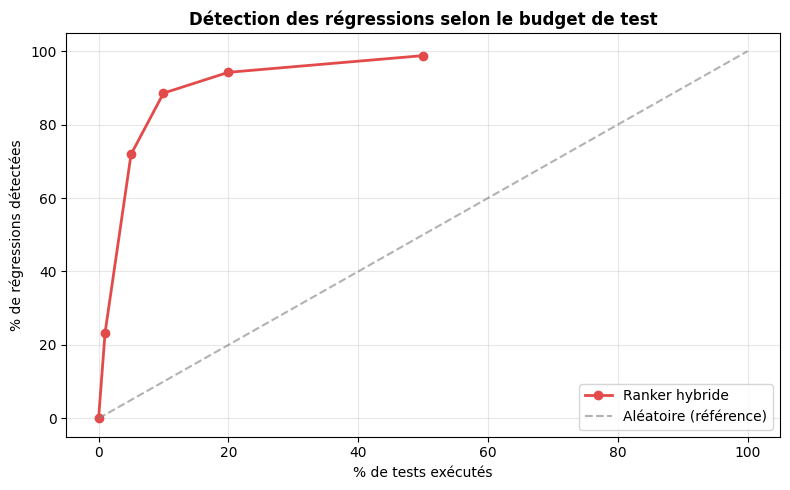

In [8]:
# ── VALIDATION 2 : coût/gain — % de tests exécutés vs % de fautes détectées ──
import matplotlib.pyplot as plt

print('COÛT / GAIN : combien de tests lancer pour détecter les régressions ?')

# Budgets de test évalués : pourcentage de la suite réellement exécutée.
# L'objectif est de mesurer la détection obtenue pour chaque budget.
budgets = [1, 5, 10, 20, 50]   # % de la suite exécutée
detection = {b: [] for b in budgets}

for cid in commit_ids:
    dc = df[df.commit_id == cid].copy()
    if dc.label_relevant.sum() == 0:
        continue
    total = len(dc)
    total_faults = dc.label_relevant.sum()
    # Tests triés par score du ranker (ordre de priorisation proposé)
    dc_sorted = dc.sort_values('rank_score', ascending=False).reset_index(drop=True)
    for b in budgets:
        # Nombre de tests exécutés pour ce budget (au moins 1)
        cut = max(1, int(total * b / 100))
        # Proportion de tests pertinents retrouvés dans ce budget
        found = dc_sorted.head(cut)['label_relevant'].sum()
        detection[b].append(found / total_faults * 100)

# Synthèse moyenne : taux de détection pour chaque budget de test
print(f"\nEn moyenne sur {len(detection[budgets[0]])} commits :")
for b in budgets:
    print(f"  En exécutant {b:>2}% des tests  →  {np.mean(detection[b]):5.1f}% des régressions détectées")

# Figure coût/gain : courbe du ranker vs diagonale de référence (aléatoire).
# Plus la courbe est au-dessus de la diagonale, plus le gain est important.
fig, ax = plt.subplots(figsize=(8, 5))
xs = [0] + budgets
ys = [0] + [np.mean(detection[b]) for b in budgets]
ax.plot(xs, ys, marker='o', color='#E24B4A', linewidth=2, label='Ranker hybride')
ax.plot([0, 100], [0, 100], '--', color='gray', alpha=0.6, label='Aléatoire (référence)')
ax.set_xlabel('% de tests exécutés')
ax.set_ylabel('% de régressions détectées')
ax.set_title('Détection des régressions selon le budget de test', fontweight='bold')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS / 'v5_cost_gain.png', dpi=150, bbox_inches='tight')
plt.show()